In [1]:
import os
from dotenv import load_dotenv

if os.environ.get("OPENAI_API_KEY"):
    print("OPENAI_API_KEY is available")
else:
    raise ValueError("OPENAI_API_KEY is not available")

print()

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model = "gpt-5.4-nano",
    temperature = 0.7
)

llm

OPENAI_API_KEY is available



ChatOpenAI(output_version=None, profile={'name': 'GPT-5.4 nano', 'release_date': '2026-03-17', 'last_updated': '2026-03-17', 'open_weights': False, 'max_input_tokens': 400000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001FD5F52C980>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001FD5FAD59D0>, root_client=<openai.OpenAI object at 0x000001FD5F4C3650>, root_async_client=<openai.AsyncOpenAI object at 0x000001FD5F9A1790>, model_name='gpt-5.4-nano', model_kwargs={

### **LLM Pydantic Schema**

In [2]:
from pydantic import BaseModel, Field
from typing import Literal

class LLMSchema(BaseModel):
    category: Literal["insta", "twitter", "linkedin"] = Field(description= "category of the post to generate")
    topic: str = Field(description="Topic of the post to generate")

In [3]:
llm_with_schema = llm.with_structured_output(LLMSchema)

In [4]:
llm_with_schema.invoke("I want to generate the post for linkedin about langgraph")

LLMSchema(category='linkedin', topic='LangGraph: building reliable, stateful AI agent workflows with graph-based orchestration')

### **Post Schema**

In [5]:
class GraphSchema(BaseModel):

    input: str
    topic: str
    post: str
    category: str


In [6]:
def decider_node(state: GraphSchema) -> GraphSchema:

    # Convert pytantic scema into a dictionary
    state = state.model_dump()

    # Extract the input from state
    user_input = state["input"]

    # passing the user input to the LLM to decide the category of the post to generate
    response = llm_with_schema.invoke(user_input)

    # Extracting the category from pydantic object
    category = response.category

    # Extracting the topic from pydantic object
    topic = response.topic

    # update the state with the decided category and topic
    state["category"] = category
    state["topic"] = topic

    return state

In [7]:
def create_post_insta(state : GraphSchema) -> GraphSchema:

    # Convert pytantic scema into a dictionary
    state = state.model_dump()

    # Extract the topics from the state
    topic = state["topic"]

    # passing the topic into llm to generate the post
    post = llm.invoke(f"Genrate an Instagram post about {topic}. Keep the tone casual and engaging").content

    # Update the post with generated post
    state["post"] = post

    return {"post": post}


def create_post_twitter(state : GraphSchema) -> GraphSchema:

    # Convert pytantic scema into a dictionary
    state = state.model_dump()

    # Extract the topics from the state
    topic = state["topic"]

    # passing the topic into llm to generate the post
    post = llm.invoke(f"Genrate the twitter post about {topic}. Keep the tone casual and quick").content

    # Update the post with generated post
    state["post"] = post

    return {"post": post}


def create_post_linkedin(state : GraphSchema) -> GraphSchema:

    # Convert pytantic scema into a dictionary
    state = state.model_dump()

    # Extract the topics from the state
    topic = state["topic"]

    # passing the topic into llm to generate the post
    post = llm.invoke(f"Genrate the LinkedIn post about {topic}. Keep the tone professional and informative").content

    # Update the post with generated post
    state["post"] = post

    return {"post": post}

In [8]:
def condition(state: GraphSchema) -> str:

    # Convert pytantic scema into a dictionary
    state = state.model_dump()

    category = state["category"]

    if category == "insta":
        return "create_post_insta"
    elif category == "twitter":
        return "create_post_twitter"
    elif category == "linkedin":
        return "create_post_linkedin"
    else:
        raise ValueError("Invalid Category")

In [9]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(GraphSchema)

# Create Node
graph.add_node("decider", decider_node)
graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_twitter", create_post_twitter)
graph.add_node("create_post_linkedin", create_post_linkedin)

# Create Edge
graph.add_edge(START, "decider")
graph.add_conditional_edges("decider", condition, {
    "create_post_insta": "create_post_insta",
    "create_post_twitter": "create_post_twitter",
    "create_post_linkedin": "create_post_linkedin"
})
graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_twitter", END)
graph.add_edge("create_post_linkedin", END)

route_graph = graph.compile()

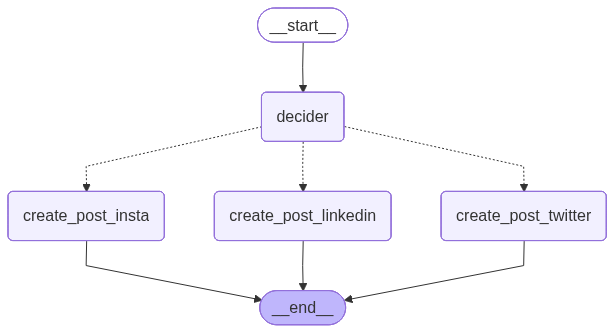

In [10]:
from IPython.display import Image, display

Image(route_graph.get_graph().draw_mermaid_png())

In [12]:
route_graph.invoke(
    {
        "input": "i want to generate a post for linkedin about interesting fact about langgraph",
        "topic":"",
        "post": "",
        "category": ""
    }
)

{'input': 'i want to generate a post for linkedin about interesting fact about langgraph',
 'topic': 'Interesting fact about LangGraph: it’s designed for building LLM workflows as stateful graphs (with explicit state and edges), which makes complex, multi-step agent behavior more controllable and debuggable than linear chains.',
 'post': '🚀 **Interesting fact about LangGraph:**  \nLangGraph is built specifically for creating **LLM workflows as *stateful graphs***—with **explicit state** and **clearly defined edges** between steps.  \n\nCompared to traditional **linear chains**, this graph-based approach makes it easier to:  \n✅ **Control** complex, multi-step agent behavior  \n✅ **Debug** where things go wrong (step-by-step flow)  \n✅ **Maintain state** across turns and iterations  \n\nIn short: **more structure, more transparency, and more reliability** for sophisticated agent systems.  \n\n#LangGraph #LLM #AgenticAI #MachineLearning #AIEngineering #SoftwareEngineering',
 'category': 